In [1]:
%pip install --quiet --upgrade langchain-text-splitters langchain-community
%pip install -qU langchain-aws
%pip install -q beautifulsoup4 langgraph
%pip install unstructured -q

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [1]:
from langchain_aws import ChatBedrock

llm = ChatBedrock(model="anthropic.claude-3-5-sonnet-20240620-v1:0",
    beta_use_converse_api=True)

In [2]:
from langchain_aws import BedrockEmbeddings

embeddings = BedrockEmbeddings(model_id="amazon.titan-embed-text-v2:0")

In [3]:
from langchain_core.vectorstores import InMemoryVectorStore

vector_store = InMemoryVectorStore(embeddings)

In [4]:
import bs4
from langchain import hub
from langchain_community.document_loaders import WebBaseLoader
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import START, StateGraph
from typing_extensions import List, TypedDict

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [5]:
# # Load and chunk contents of the blog
# loader = WebBaseLoader(
#     web_paths=("https://lilianweng.github.io/posts/2023-06-23-agent/",),
#     bs_kwargs=dict(
#         parse_only=bs4.SoupStrainer(
#             class_=("post-content", "post-title", "post-header")
#         )
#     ),
# )
# docs = loader.load()

In [24]:
%pip install "unstructured[md]"

Note: you may need to restart the kernel to use updated packages.


In [25]:
from langchain_community.document_loaders import DirectoryLoader

loader = DirectoryLoader("./", glob=["**/*.py", "**/*.md", "**/*.html", "**/*.js", "**/*.yaml"])
docs = loader.load()
len(docs)

32

In [26]:
docs

[Document(metadata={'source': 'simulation.py'}, page_content='# simulation.py\n\nimport logging\n\nimport numpy as np\n\nimport pandas as pd\n\nfrom lib.reactor_settings import ReactorSettings\n\nfrom lib.storage_tank import StorageTank\n\nfrom lib.power_system import PowerSystem\n\nfrom lib.atmosphere_intake_system import AtmosphereIntakeSystem\n\nfrom lib.containment_vessel import ContainmentVessel\n\nfrom lib.sabatier_reactor import SabatierReactor\n\nfrom lib.electrolysis_reactor import ElectrolysisReactor\n\nlogger = logging.getLogger(__name__)\n\nlogger.setLevel(logging.INFO)\n\ndef run_simulation(sim_speed=1.0, sim_duration=0.1): # Storage tanks for reactants and products settings = ReactorSettings() CO2_tank = StorageTank("CO2", capacity=10000) H2_tank = StorageTank("H2", capacity=5000, level=400) CH4_tank = StorageTank("CH4", capacity=3000) H2O_tank = StorageTank("H2O", capacity=2000) O2_tank = StorageTank("O2", capacity=5000)\n\n# Environmental cycles # Define Mars-specific c

In [27]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
all_splits = text_splitter.split_documents(docs)

In [28]:
# Index chunks
_ = vector_store.add_documents(documents=all_splits)

In [29]:
# Define prompt for question-answering
prompt = hub.pull("rlm/rag-prompt")

# Define state for application
class State(TypedDict):
    question: str
    context: List[Document]
    answer: str


# Define application steps
def retrieve(state: State):
    retrieved_docs = vector_store.similarity_search(state["question"])
    return {"context": retrieved_docs}


def generate(state: State):
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])
    messages = prompt.invoke({"question": state["question"], "context": docs_content})
    response = llm.invoke(messages)
    return {"answer": response.content}

/Users/matt/Code/PyISRU/.venv/lib/python3.12/site-packages/langsmith/client.py:261: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


In [30]:
prompt

ChatPromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, metadata={'lc_hub_owner': 'rlm', 'lc_hub_repo': 'rag-prompt', 'lc_hub_commit_hash': '50442af133e61576e74536c6556cefe1fac147cad032f4377b60c436e6cdcb6e'}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template="You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.\nQuestion: {question} \nContext: {context} \nAnswer:"), additional_kwargs={})])

In [31]:
# Compile application and test
graph_builder = StateGraph(State).add_sequence([retrieve, generate])
graph_builder.add_edge(START, "retrieve")
graph = graph_builder.compile()

In [32]:
response = graph.invoke({"question": "Whats this project about?"})
print(response["answer"])

This project appears to be a CDK (Cloud Development Kit) Python project for simulating a power generation and chemical processing system. It involves simulating cycles of atmosphere intake, Sabatier reaction, and electrolysis over multiple time steps, while tracking various resource levels and power generation. The project is set up with a Python virtual environment for managing dependencies.


In [33]:
response = graph.invoke({"question": "How can we improve the ElectrolysisReactor class?"})
print(response["answer"])

To improve the ElectrolysisReactor class, we could add error handling and input validation to ensure the parameters are within expected ranges. We could also implement a method to calculate and track the reactor's efficiency over time. Additionally, adding more detailed logging or monitoring capabilities would help in debugging and performance analysis.


In [36]:
response = graph.invoke({"question": "What's the SabatierReactor class do?"})
print(response["answer"])

The SabatierReactor class represents a Sabatier reactor in a simulation. It contains properties such as efficiency, catalyst degradation rate, temperature and pressure cycles, storage tanks for various gases, and a power system. The class is likely used to model and simulate the behavior of a Sabatier reactor in a larger system or process.


In [35]:
response = graph.invoke({"question": "What are some suggestions on how we could improve the realism of the simulation?"})
print(response["answer"])

To improve the realism of the simulation, we could focus on three key areas:

1. Enhance environmental factors by incorporating more detailed Martian weather patterns, including dust storms and seasonal variations.

2. Implement more complex system interactions, such as the effects of equipment degradation over time and the impact of radiation on various components.

3. Include unexpected events or failures to test the system's resilience and allow users to develop contingency plans.


In [14]:
from langchain_core.prompts import PromptTemplate



template = """Use the following pieces of context to answer the question at the end.
If you don't know the answer, just say that you don't know, don't try to make up an answer.
Use three sentences maximum and keep the answer as concise as possible.
Always say "thanks for asking!" at the end of the answer.

{context}

Question: {question}

Helpful Answer:"""
custom_rag_prompt = PromptTemplate.from_template(template)

In [15]:
custom_rag_prompt

PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template='Use the following pieces of context to answer the question at the end.\nIf you don\'t know the answer, just say that you don\'t know, don\'t try to make up an answer.\nUse three sentences maximum and keep the answer as concise as possible.\nAlways say "thanks for asking!" at the end of the answer.\n\n{context}\n\nQuestion: {question}\n\nHelpful Answer:')

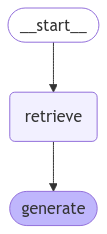

In [13]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))